# Rekomendacja: przesunięcie zużycia w dobie

**Pytanie tego notebooka:** ile realnie oszczędza odbiorca, który przesuwa część zużycia
na tańsze kwadranse tej samej doby?

Dane: `data/processed/energia_pl.csv`, 76 512 kwadransów z okresu 14.06.2024 - 19.08.2026.
Główna zmienna to `rce_pln`, czyli rynkowa cena energii w PLN/MWh. Ceny są publikowane dzień
wcześniej (kolumna `publication_ts`), więc odbiorca zna je z wyprzedzeniem i może zaplanować
zużycie. Na tym opiera się cała rekomendacja.

Zastrzeżenie: RCE to nie jest cena z faktury. Wyniki dotyczą odbiorcy rozliczanego według
ceny rynkowej.

## 1. Wczytanie i kontrola danych

In [1]:
import pandas as pd
from pathlib import Path

In [2]:
PROJECT_DIR = Path.cwd().resolve().parent
PROCESSED_CSV = PROJECT_DIR / "data" / "processed" / "energia_pl.csv"

In [3]:
df = pd.read_csv(PROCESSED_CSV)
df.shape

(76512, 17)

## 2. Koszt bazowy profilu płaskiego

In [4]:
baseline_cost = df["rce_pln"].mean()
print(f"baseline cost: {baseline_cost:.2f} PLN/MWh")

baseline cost: 457.71 PLN/MWh


In [5]:
df["price_rank_in_day"] = df.groupby("business_date")["rce_pln"].rank(method="first")
print(f"rank range: {df['price_rank_in_day'].min()} - {df['price_rank_in_day'].max()}")

rank range: 1.0 - 100.0


In [6]:
df["day_size"] = df.groupby("business_date")["rce_pln"].transform("size")
print(df["day_size"].unique())

[ 96 100  92]


### Pozycja w dobie odporna na zmianę czasu

`day_size` ma trzy wartości: 96, 100 i 92. Krótsze i dłuższe doby to dni zmiany czasu.

Ma to znaczenie dla modelu. Gdyby koszyk liczyć stałą liczbą kwadransów, „najtańsze 24"
znaczyłoby 25% zużycia w dobie 96-kwadransowej i 24% w dobie 100-kwadransowej. Ten sam model
liczyłby więc co innego w zależności od dnia.

Dlatego zamiast surowego rankingu używam **pozycji znormalizowanej**: ranking dzielony przez
liczbę kwadransów w tej dobie, przesunięty o pół kwadransa, żeby wartości leżały symetrycznie
między 0 a 1. Wtedy `day_position <= 0.2` znaczy „najtańsze 20% doby" w każdym dniu roku,
bez względu na jego długość.

`method="first"` w rankingu to wybór świadomy. Przy 99 kwadransach o cenie zero remisy się
zdarzają, a „first" rozstrzyga je jednoznacznie i dzieli dobę na rozłączne koszyki. Który
kwadrans trafi do koszyka przy równych cenach, nie zmienia kosztu.

In [7]:
df["day_position"] = (df["price_rank_in_day"] - 0.5) / df["day_size"]
print(f"day position range: {df['day_position'].min():.4f} - {df['day_position'].max():.4f}")
print(f"quarters in cheapest 20%: {(df['day_position'] <= 0.20).sum()} of {len(df)}")

day position range: 0.0050 - 0.9950
quarters in cheapest 20%: 15143 of 76512


## 3. Model przesunięcia zużycia

**Odbiorca:** profil płaski, czyli zużywa tyle samo w każdym kwadransie doby. Jego koszt
to zwykła średnia ceny.

**Działanie:** przenosi `f` procent dobowego zużycia z **najdroższych** `f` procent kwadransów
do **najtańszych** `f` procent kwadransów tego samego dnia. Przy płaskim profilu najdroższy
koszyk zawiera dokładnie `f` zużycia doby, więc jest to to samo, co wyłączenie poboru
w najdroższych godzinach i podwojenie go w najtańszych.

**Wzór:**

```
koszt po przesunięciu = koszt bazowy - f * (średnia koszyka drogiego - średnia koszyka taniego)
```

Cała oszczędność sprowadza się więc do jednej wielkości: **spreadu między drogim a tanim
koszykiem doby**. Reszta to arytmetyka.

Trzy decyzje, które zmieniają wynik:

1. **Średnia, nie mediana.** Koszt to suma iloczynów ceny i zużycia, a nie wartość typowa.
   Mediana wycięłaby skoki cen, czyli dokładnie to, na czym ten model zarabia. W notebooku 01
   różnica między średnią a medianą sięga 42 PLN/MWh w godzinach 12-13.
2. **Liczę osobno dla każdej doby, potem uśredniam po dobach.** Gdyby percentyle liczyć na
   wszystkich 76 512 kwadransach naraz, „najtańsze 20%" oznaczałoby czerwcowe południa,
   a nie najtańsze godziny każdego dnia. Model ma odwzorować odbiorcę, który codziennie
   po południu patrzy na ceny na jutro.
3. **Tylko w ramach doby.** RCE jest publikowana dzień naprzód, więc dalej niż na jedną dobę
   nie da się planować.

**Ograniczenie z konstrukcji:** `f` musi być mniejsze od 0,5, inaczej koszyki zaczęłyby
na siebie zachodzić.

In [8]:
def daily_shift(data, fraction):
    """Daily cost of a flat consumption profile before and after moving `fraction`
    of the daily volume from the most expensive to the cheapest quarters of the same day."""
    if not 0 < fraction < 0.5:
        raise ValueError("fraction must be between 0 and 0.5")

    baseline = data.groupby("business_date")["rce_pln"].mean()
    cheap = data[data["day_position"] <= fraction].groupby("business_date")["rce_pln"].mean()
    expensive = data[data["day_position"] > 1 - fraction].groupby("business_date")["rce_pln"].mean()

    result = pd.DataFrame({"baseline": baseline, "cheap": cheap, "expensive": expensive})
    result["spread"] = result["expensive"] - result["cheap"]
    result["shifted"] = result["baseline"] - fraction * result["spread"]
    result["saving"] = result["baseline"] - result["shifted"]
    return result

### Wyniki dla trzech wariantów

10% to odbiorca ostrożny, który przesuwa jedną czynność w ciągu dnia. 30% to górna granica
realizmu dla zakładu z elastyczną częścią produkcji.

In [9]:
fractions = [0.10, 0.20, 0.30]

rows = []
for fraction in fractions:
    daily = daily_shift(df, fraction)
    rows.append({
        "shift %": int(fraction * 100),
        "baseline": daily["baseline"].mean(),
        "cheap basket": daily["cheap"].mean(),
        "expensive basket": daily["expensive"].mean(),
        "spread": daily["spread"].mean(),
        "shifted cost": daily["shifted"].mean(),
        "saving PLN/MWh": daily["saving"].mean(),
        "saving %": 100 * daily["saving"].mean() / daily["baseline"].mean(),
    })

savings = pd.DataFrame(rows).set_index("shift %").round(2)
savings

,baseline,cheap basket,expensive basket,spread,shifted cost,saving PLN/MWh,saving %
shift %,,,,,,,
10,457.72,204.84,792.82,587.98,398.92,58.80,12.85
20,457.72,225.50,719.02,493.51,359.02,98.70,21.56
30,457.72,257.51,663.39,405.88,335.95,121.76,26.60


### Odczytanie tabeli

**Spread maleje, gdy koszyki się rozszerzają.** Przy 10% porównuję skrajności doby, przy 30%
do koszyków wchodzą już kwadranse przeciętne. Dlatego oszczędność rośnie wolniej niż liniowo:
podwojenie wysiłku z 10% na 20% nie podwaja efektu.

**Pierwsze 10% daje najwięcej.** Przejście z zera na 10% jest warte więcej niż przejście
z 20% na 30%. Wniosek praktyczny: nie trzeba przebudowywać całego profilu, żeby zobaczyć efekt.

**Tani koszyk ma cenę wyraźnie dodatnią**, mimo 3205 kwadransów z ceną ujemną w zbiorze.
Ceny ujemne są rzadkie i skupione w słoneczne południa, więc w średniej z 797 dób
nie przeważają.

## 4. Oszczędność w funkcji skali przesunięcia

Ten sam rachunek dla wartości od 5% do 45%, żeby zobaczyć kształt zależności zamiast
trzech punktów.

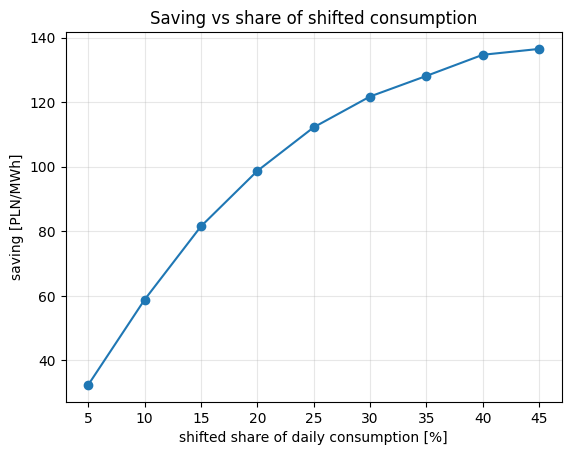

In [10]:
curve = pd.Series(
    {int(f * 100): daily_shift(df, f)["saving"].mean() for f in [i / 100 for i in range(5, 50, 5)]},
    name="saving",
)

ax = curve.plot(marker="o", title="Saving vs share of shifted consumption")
ax.set_xlabel("shifted share of daily consumption [%]")
ax.set_ylabel("saving [PLN/MWh]")
ax.grid(alpha=0.3)

Krzywa jest wklęsła: każdy kolejny procent przesuniętego zużycia daje mniej niż poprzedni.
To nie przypadek, tylko efekt rozkładu cen w dobie - koszyki rozszerzają się w stronę środka,
gdzie ceny są przeciętne.

## 5. Jak to wygląda w jednej dobie

Tabela z uśrednionymi liczbami nie pokazuje, co odbiorca faktycznie robi, dlatego jeden dzień
na wykresie. Celowo nie wybieram doby rekordowej - pojedynczy spektakularny przypadek zawyżyłby
wrażenie z całości.

Doba typowa musi być typowa pod **dwoma** względami naraz. Sam spread nie wystarczy: dzień
o medianowym spreadzie może mieć ceny dużo niższe od przeciętnych i wykres mylnie pokazywałby
skalę. Dlatego najpierw zawężam zbiór do dób o poziomie cen w rozstępie ćwiartkowym, a dopiero
wśród nich szukam tej o spreadzie najbliższym medianie.

example day: 2024-08-07
spread: 471.82 PLN/MWh
baseline: 433.12 -> shifted: 338.75


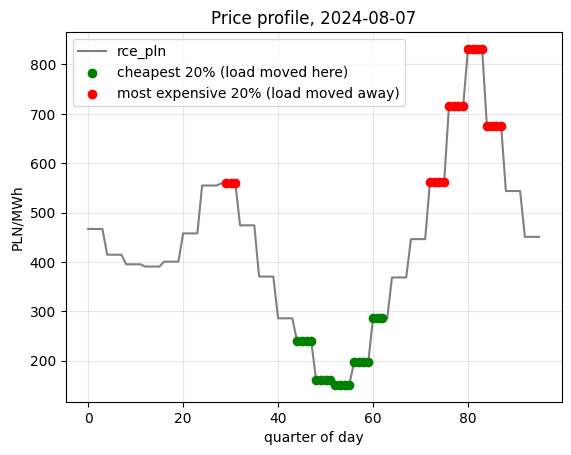

In [11]:
daily_20 = daily_shift(df, 0.20)

q1, q3 = daily_20["baseline"].quantile([0.25, 0.75])
typical_level = daily_20[daily_20["baseline"].between(q1, q3)]
example_date = (typical_level["spread"] - daily_20["spread"].median()).abs().idxmin()

day = df[df["business_date"] == example_date].sort_values("dtime").reset_index(drop=True)
cheap_mask = day["day_position"] <= 0.20
expensive_mask = day["day_position"] > 0.80

ax = day["rce_pln"].plot(color="grey", title=f"Price profile, {example_date}")
ax.scatter(day.index[cheap_mask], day.loc[cheap_mask, "rce_pln"],
           color="green", zorder=3, label="cheapest 20% (load moved here)")
ax.scatter(day.index[expensive_mask], day.loc[expensive_mask, "rce_pln"],
           color="red", zorder=3, label="most expensive 20% (load moved away)")
ax.set_xlabel("quarter of day")
ax.set_ylabel("PLN/MWh")
ax.grid(alpha=0.3)
ax.legend()

print(f"example day: {example_date}")
print(f"spread: {daily_20.loc[example_date, 'spread']:.2f} PLN/MWh")
print(f"baseline: {daily_20.loc[example_date, 'baseline']:.2f} -> shifted: {daily_20.loc[example_date, 'shifted']:.2f}")

## 6. Czy opłacalność rośnie rok do roku

Z notebooka 01 wynika, że rośnie **amplituda doby**, a nie że dolina cenowa się pogłębia.
Oszczędność zależy wprost od spreadu w dobie, więc płynie stąd przewidywanie: przesuwanie
zużycia powinno opłacać się z roku na rok bardziej.

**Porównanie musi iść po tym samym oknie kalendarzowym.** Dane zaczynają się 14.06.2024,
więc rok 2024 to samo lato, a zestawienie go z pełnymi latami dałoby artefakt składu próby.
To ten sam błąd, który w notebooku 01 obalił hipotezę o pogłębiającej się dolinie. Zostają
lata 2025 i 2026 w oknie 1 stycznia - 19 sierpnia.

In [12]:
business_date = pd.to_datetime(df["business_date"])
df["year"] = business_date.dt.year

same_window = df[business_date.dt.strftime("%m-%d") <= "08-19"]
comparable_years = same_window[same_window["year"].isin([2025, 2026])]

rows = []
for year, subset in comparable_years.groupby("year"):
    daily = daily_shift(subset, 0.20)
    rows.append({
        "year": year,
        "days": len(daily),
        "baseline": daily["baseline"].mean(),
        "spread": daily["spread"].mean(),
        "saving PLN/MWh": daily["saving"].mean(),
        "saving %": 100 * daily["saving"].mean() / daily["baseline"].mean(),
    })

yearly_saving = pd.DataFrame(rows).set_index("year").round(2)
yearly_saving

,days,baseline,spread,saving PLN/MWh,saving %
year,,,,,
2025,231,424.24,465.86,93.17,21.96
2026,231,482.66,561.83,112.37,23.28


### Wynik: potwierdza się w złotówkach, nie w procentach

Spread rośnie, a razem z nim oszczędność w PLN/MWh - zgodnie z przewidywaniem. Ale oszczędność
**procentowa** rośnie dużo słabiej, bo w 2026 podniósł się także poziom bazowy cen. Z notebooka
01 wiadomo, że cały profil poza południem przesunął się w górę o około 40%; przyczyn tego zbiór
nie wyjaśnia, bo nie ma w nim kosztów paliw ani uprawnień do emisji CO2.

Uczciwie brzmi to tak: **rośnie kwota oszczędności, a nie jej udział w rachunku**. Dwa lata
to za mało na tezę o trendzie - to jedna obserwacja zgodna z przewidywaniem, a nie jego dowód.

## Ograniczenia

**RCE to nie faktura.** Odbiorca końcowy płaci dodatkowo opłatę dystrybucyjną, opłatę mocową
i akcyzę, a te w większości nie zależą od godziny poboru. Policzona tu oszczędność dotyczy
samego składnika energii, więc w całym rachunku będzie procentowo mniejsza.

**Pełna elastyczność.** Model zakłada, że przesuwaną część zużycia da się przenieść w dowolny
kwadrans doby, bez kosztu i bez strat. Realny odbiorca ma ograniczenia technologiczne,
a najtańsze kwadranse bywają rozrzucone po dobie zamiast tworzyć jeden ciągły blok.

**Koszyki zaokrąglane w dół.** Przy 96 kwadransach koszyk „20%" liczy 19 kwadransów, czyli
19,8%. Odchylenie jest takie samo po obu stronach doby, więc nie przesuwa wyniku w żadną
stronę, ale nie jest to dokładnie 20%.

**Brak ryzyka prognozy.** Ceny są znane dzień wcześniej, więc model niczego nie przewiduje.
To mocna strona rekomendacji, ale zawęża ją do odbiorców rozliczanych według ceny rynkowej,
a nie taryfy stałej.

**Okno danych 14.06.2024 - 19.08.2026**, 797 dób. To mniej niż pełne dwa lata i bez zimy 2024.

## Wniosek

Odbiorca o płaskim profilu, rozliczany według RCE, może obniżyć koszt energii bez żadnej
inwestycji - wystarczy harmonogram i ceny opublikowane dzień wcześniej. Przesunięcie 20%
zużycia z najdroższych do najtańszych kwadransów **tej samej doby** daje 98,70 PLN/MWh,
czyli 21,6% kosztu.

Efekt bierze się z jednej wielkości: spreadu między drogim a tanim koszykiem doby. Ten spread
to skutek dobowego profilu cen z notebooka 01 (dolina w południe, szczyt wieczorem)
i wypierania droższych jednostek przez OZE z notebooka 02. Trzy notebooki układają się więc
w jeden łańcuch: **skąd bierze się kształt doby, dlaczego się pogłębia i ile na tym może
zyskać odbiorca**.

Zależność jest wklęsła, więc pierwsze przesunięte procenty zużycia są najcenniejsze -
rekomendacja nie wymaga przebudowy całego profilu.

Kwota oszczędności rośnie rok do roku wraz z amplitudą doby, ale jej udział w rachunku
już nie, bo równolegle rósł ogólny poziom cen. Dwa porównywalne lata to za mało na tezę
o trendzie.